# 06. Predicción estadística de Hs para 2027

## Aplicación a la gestión portuaria de Gijón y Bilbao

Este notebook construye una **predicción mensual de la altura significativa del oleaje (Hs) para 2027** a partir de las cuatro series de boyas del TFM y de un periodo histórico exacto de **20 años: 2005–2024**.

 La variable central es Hs porque es la referencia principal del TFM para describir la intensidad del estado del mar. La dirección se incorpora al final como **contexto climatológico mensual**, no como una media angular ordinaria.

> **Alcance:** se predice la media mensual de Hs. El resultado sirve para planificación preventiva y comparación estacional, ayuda en los límites de gestión porturaia operativos de cada puerto como infomración básica para trabajos detallados y/O información de partida

## 1. Criterios estadísticos utilizados

| Criterio | Decisión adoptada | Motivo |
|---|---|---|
| Frecuencia | Mensual | Un horizonte hasta 2027 no justifica una predicción horaria o diaria con falsa precisión. |
| Calidad mensual | Al menos 70 % de horas con Hs | Evita que una media calculada con pocas horas represente todo el mes. |
| Validación | Entrenamiento 2005–2021 y prueba 2022–2024 | La separación es cronológica y reproduce un horizonte futuro de 36 meses. |
| Modelo de referencia | Ingenuo estacional | Pronostica cada mes repitiendo el patrón de los últimos 12 meses. |
| Modelo principal | Holt-Winters/ETS aditivo con tendencia amortiguada | Resume nivel, tendencia suave y estacionalidad anual sin variables artificiales. |
| Selección | Menor MAE en validación | El MAE se expresa en metros y es fácil de interpretar. |
| Incertidumbre | P10–P90 de los errores de validación | Banda empírica y transparente; no se presenta como intervalo meteorológico exacto. |

El modelo Holt-Winters puede resumirse como:

$$y_t = \text{nivel}_t + \text{tendencia amortiguada}_t + \text{estacionalidad}_{t,12} + \varepsilon_t$$

El modelo ingenuo estacional utiliza $\hat y_t = y_{t-12}$. Compararlo con ETS evita aceptar un modelo más elaborado si no mejora una referencia sencilla.

In [ ]:

import importlib.util
import subprocess
import sys

if importlib.util.find_spec("statsmodels") is None:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "statsmodels==0.14.4"
    ])

print("Dependencias preparadas.")

Dependencias preparadas.


In [ ]:
import os
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.holtwinters import ExponentialSmoothing

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

COBERTURA_MINIMA = 0.70
INICIO_HISTORICO = pd.Timestamp("2005-01-01")
FIN_HISTORICO = pd.Timestamp("2024-12-31 23:59:59")
INICIO_VALIDACION = pd.Timestamp("2022-01-01")
FIN_VALIDACION = pd.Timestamp("2024-12-01")
HORIZONTE_MESES = 36

MESES_ES = {
    1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril",
    5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto",
    9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"
}

COLORES = {
    "historico": "#334155",
    "pronostico": "#0077B6",
    "banda": "#90E0EF",
    "observado": "#111827",
    "invalido": "#F59E0B",
}

plt.rcParams.update({
    "figure.figsize": (14, 6),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

def localizar_dataset():
    candidatos = [
        os.environ.get("TFM_DATASET_PATH"),
        "/content/dataset_principal_oleaje.csv",
        "dataset_principal_oleaje.csv",
        "../data/processed/dataset_principal_oleaje.csv",
    ]
    for candidato in candidatos:
        if candidato and Path(candidato).exists():
            return Path(candidato)

    try:
        from google.colab import files
        print("Selecciona dataset_principal_oleaje.csv")
        subidos = files.upload()
        if subidos:
            return Path(next(iter(subidos)))
    except ImportError:
        pass

    raise FileNotFoundError(
        "No se encontró dataset_principal_oleaje.csv. Súbelo a Colab o define "
        "la variable de entorno TFM_DATASET_PATH."
    )

RUTA_DATOS = localizar_dataset()
CARPETA_RESULTADOS = Path(
    os.environ.get("TFM_OUTPUT_DIR", "/content/resultados_notebook_06")
)
CARPETA_TABLAS = CARPETA_RESULTADOS / "tablas"
CARPETA_FIGURAS = CARPETA_RESULTADOS / "figuras"
CARPETA_TABLAS.mkdir(parents=True, exist_ok=True)
CARPETA_FIGURAS.mkdir(parents=True, exist_ok=True)

print("Dataset:", RUTA_DATOS)
print("Resultados:", CARPETA_RESULTADOS)

Selecciona dataset_principal_oleaje.csv


Saving dataset_principal_oleaje.csv to dataset_principal_oleaje.csv
Dataset: dataset_principal_oleaje.csv
Resultados: /content/resultados_notebook_06


## 2. Carga, selección temporal y control inicial

Se utilizan únicamente las columnas necesarias. El filtro temporal excluye el registro de 2004 y conserva exactamente desde el 1 de enero de 2005 hasta el 31 de diciembre de 2024.

In [ ]:
columnas = [
    "fecha", "codigo_boya", "nombre_boya", "zona", "tipo_boya",
    "Hs_m", "dir_media_oleaje_grados"
]

datos = pd.read_csv(
    RUTA_DATOS,
    usecols=columnas,
    parse_dates=["fecha"],
    low_memory=False,
)

for col in ["Hs_m", "dir_media_oleaje_grados"]:
    datos[col] = pd.to_numeric(datos[col], errors="coerce")

filas_iniciales = len(datos)
datos = datos.loc[
    datos["fecha"].between(INICIO_HISTORICO, FIN_HISTORICO)
].copy()

duplicados = int(datos.duplicated(["codigo_boya", "fecha"]).sum())
if duplicados:
    datos = datos.sort_values("fecha").drop_duplicates(
        ["codigo_boya", "fecha"], keep="last"
    )

# Hs no puede ser negativa. Los nulos se conservan para medir cobertura.
datos.loc[datos["Hs_m"] < 0, "Hs_m"] = np.nan
datos = datos.sort_values(["codigo_boya", "fecha"]).reset_index(drop=True)

horas_teoricas = len(pd.date_range(
    INICIO_HISTORICO, FIN_HISTORICO.floor("h"), freq="h"
))

resumen_calidad = (
    datos.groupby(["codigo_boya", "nombre_boya", "zona", "tipo_boya"], observed=True)
    .agg(
        fecha_inicio=("fecha", "min"),
        fecha_fin=("fecha", "max"),
        registros=("fecha", "size"),
        Hs_validas=("Hs_m", "count"),
    )
    .reset_index()
)
resumen_calidad["cobertura_temporal_pct"] = (
    100 * resumen_calidad["registros"] / horas_teoricas
).round(2)
resumen_calidad["Hs_validas_pct_sobre_registros"] = (
    100 * resumen_calidad["Hs_validas"] / resumen_calidad["registros"]
).round(2)

print(f"Filas del CSV completo: {filas_iniciales:,}")
print(f"Filas utilizadas (2005–2024): {len(datos):,}")
print(f"Duplicados boya-fecha eliminados: {duplicados}")
print(f"Horas teóricas por boya en 20 años: {horas_teoricas:,}")
display(resumen_calidad)

assert datos["fecha"].min() >= INICIO_HISTORICO
assert datos["fecha"].max() <= FIN_HISTORICO
assert datos["codigo_boya"].nunique() == 4

Filas del CSV completo: 610,438
Filas utilizadas (2005–2024): 610,414
Duplicados boya-fecha eliminados: 0
Horas teóricas por boya en 20 años: 175,320


,codigo_boya,nombre_boya,zona,tipo_boya,fecha_inicio,fecha_fin,registros,Hs_validas,cobertura_temporal_pct,Hs_validas_pct_sobre_registros
0,1103,Bilbao costera,Bilbao,Costera,2005-01-01 00:00:00,2024-12-31 23:00:00,140991,140988,80.42,100.0
1,1117,Gijón costera,Gijón,Costera,2005-01-05 09:00:00,2024-12-31 23:00:00,150719,150719,85.97,100.0
2,2136,Bilbao-Vizcaya,Bilbao-Vizcaya,Exterior,2005-01-01 00:00:00,2024-12-31 23:00:00,162793,162789,92.85,100.0
3,2242,Cabo de Peñas,Asturias/Gijón,Exterior,2005-01-01 00:00:00,2024-12-31 23:00:00,155911,155911,88.93,100.0


## 3. Construcción de la serie mensual

Para cada boya y mes se calcula la media de Hs y el porcentaje de horas disponibles respecto a las horas teóricas del calendario. Cuando la cobertura es inferior al 70 %, la media se considera insuficientemente representativa y se marca como ausente.

ETS necesita una serie regular, sin huecos. Por eso los meses no válidos se sustituyen **solo para ajustar el modelo** por la mediana histórica del mismo mes del año y de la misma boya. La tabla exportada conserva la cobertura y la marca de imputación para que el procedimiento sea auditable.

In [ ]:
datos["fecha_mes"] = datos["fecha"].dt.to_period("M").dt.to_timestamp()

mensual_observada = (
    datos.groupby(["codigo_boya", "nombre_boya", "fecha_mes"], observed=True)
    .agg(
        horas_registradas=("fecha", "size"),
        horas_Hs_validas=("Hs_m", "count"),
        Hs_media_calculada_m=("Hs_m", "mean"),
    )
    .reset_index()
)

boyas = (
    datos[["codigo_boya", "nombre_boya"]]
    .drop_duplicates()
    .sort_values("codigo_boya")
    .reset_index(drop=True)
)
fechas_mensuales = pd.date_range("2005-01-01", "2024-12-01", freq="MS")

rejilla = pd.MultiIndex.from_product(
    [boyas["codigo_boya"], fechas_mensuales],
    names=["codigo_boya", "fecha_mes"],
).to_frame(index=False)
rejilla = rejilla.merge(boyas, on="codigo_boya", how="left")

serie_mensual = rejilla.merge(
    mensual_observada,
    on=["codigo_boya", "nombre_boya", "fecha_mes"],
    how="left",
)
serie_mensual["horas_registradas"] = serie_mensual["horas_registradas"].fillna(0).astype(int)
serie_mensual["horas_Hs_validas"] = serie_mensual["horas_Hs_validas"].fillna(0).astype(int)
serie_mensual["horas_teoricas_mes"] = (
    serie_mensual["fecha_mes"].dt.days_in_month * 24
)
serie_mensual["cobertura_Hs"] = (
    serie_mensual["horas_Hs_validas"] / serie_mensual["horas_teoricas_mes"]
)
serie_mensual["mes_valido"] = serie_mensual["cobertura_Hs"] >= COBERTURA_MINIMA
serie_mensual["Hs_media_observada_m"] = serie_mensual[
    "Hs_media_calculada_m"
].where(serie_mensual["mes_valido"])

def imputar_por_mes_del_ano(tabla, columna="Hs_media_observada_m"):
    # Rellena huecos con la mediana del mismo mes del año sin alterar la observación.
    aux = tabla.sort_values("fecha_mes").copy()
    aux["numero_mes"] = aux["fecha_mes"].dt.month
    medianas_mes = aux.groupby("numero_mes")[columna].median()
    mediana_global = aux[columna].median()
    imputada = aux[columna].copy()
    faltan = imputada.isna()
    imputada.loc[faltan] = aux.loc[faltan, "numero_mes"].map(medianas_mes)
    imputada = imputada.fillna(mediana_global)
    return pd.Series(imputada.to_numpy(), index=aux["fecha_mes"], dtype=float)

partes = []
for _, grupo in serie_mensual.groupby("codigo_boya", observed=True):
    grupo = grupo.sort_values("fecha_mes").copy()
    s_modelo = imputar_por_mes_del_ano(grupo)
    grupo["Hs_media_modelo_m"] = s_modelo.to_numpy()
    grupo["valor_imputado"] = grupo["Hs_media_observada_m"].isna()
    partes.append(grupo)

serie_mensual = pd.concat(partes, ignore_index=True)

resumen_meses = (
    serie_mensual.groupby(["codigo_boya", "nombre_boya"], observed=True)
    .agg(
        meses_totales=("fecha_mes", "size"),
        meses_validos=("mes_valido", "sum"),
        meses_imputados=("valor_imputado", "sum"),
        cobertura_mediana_pct=("cobertura_Hs", lambda x: 100 * x.median()),
    )
    .reset_index()
)
resumen_meses["cobertura_mediana_pct"] = resumen_meses["cobertura_mediana_pct"].round(1)

display(resumen_meses)
assert len(serie_mensual) == 4 * 20 * 12
assert serie_mensual["Hs_media_modelo_m"].notna().all()

,codigo_boya,nombre_boya,meses_totales,meses_validos,meses_imputados,cobertura_mediana_pct
0,1103,Bilbao costera,240,185,55,99.3
1,1117,Gijón costera,240,202,38,99.7
2,2136,Bilbao-Vizcaya,240,216,24,100.0
3,2242,Cabo de Peñas,240,208,32,100.0


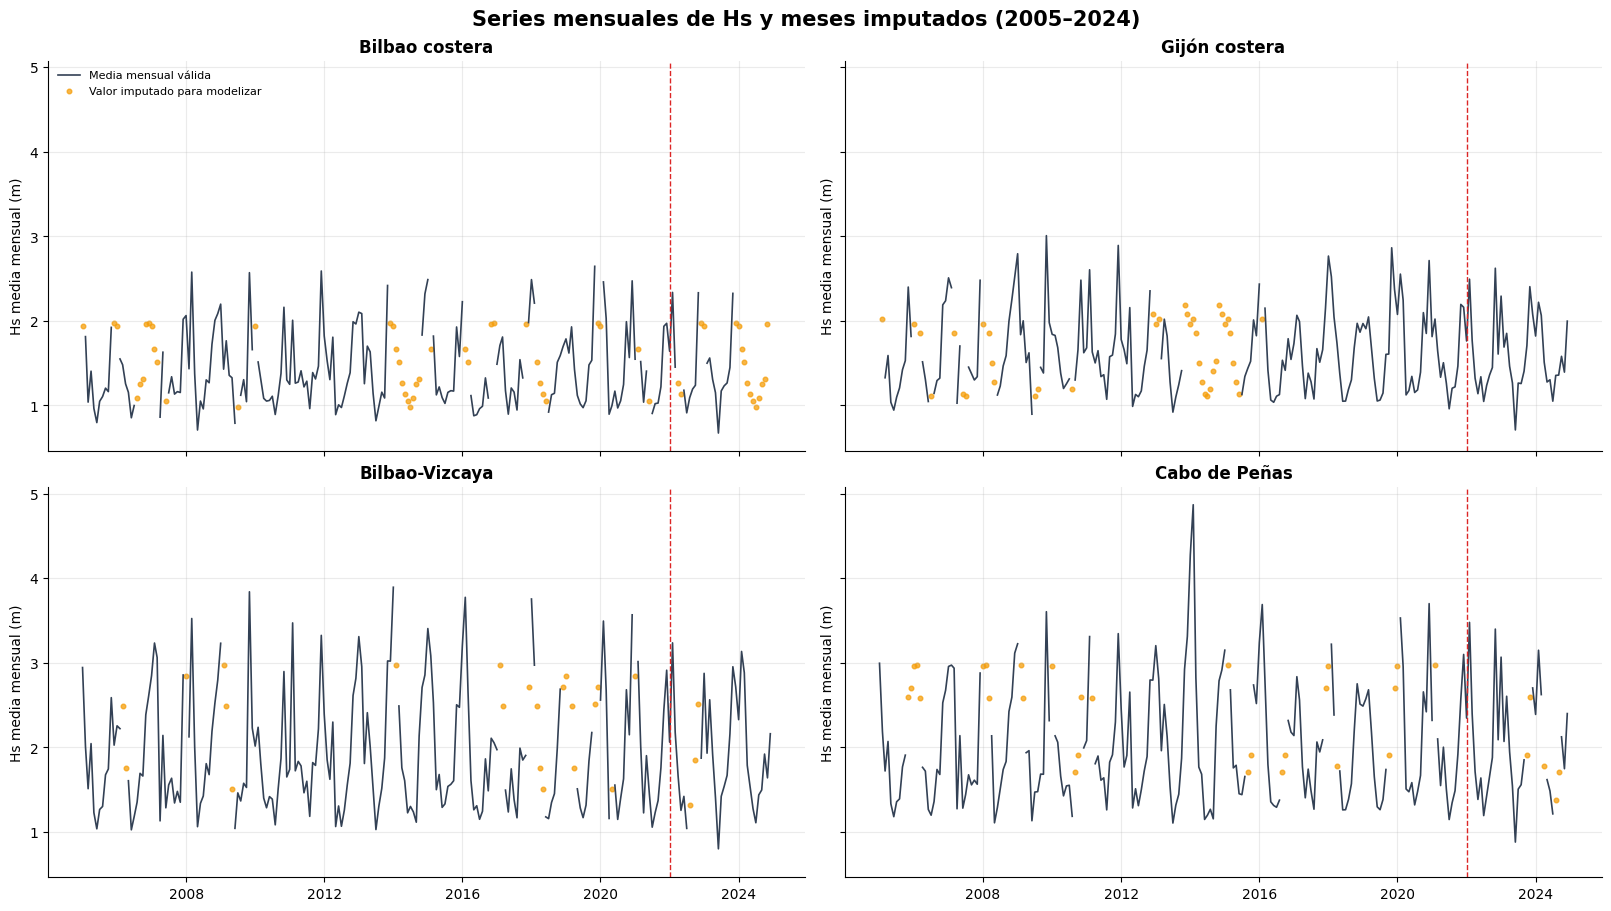

In [ ]:
orden_boyas = boyas["nombre_boya"].tolist()
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True, sharey=True, constrained_layout=True)

for ax, nombre in zip(axes.flat, orden_boyas):
    g = serie_mensual.loc[serie_mensual["nombre_boya"] == nombre]
    ax.plot(
        g["fecha_mes"], g["Hs_media_observada_m"],
        color=COLORES["historico"], linewidth=1.2, label="Media mensual válida"
    )
    imp = g.loc[g["valor_imputado"]]
    ax.scatter(
        imp["fecha_mes"], imp["Hs_media_modelo_m"], s=11,
        color=COLORES["invalido"], alpha=0.75, label="Valor imputado para modelizar"
    )
    ax.axvline(INICIO_VALIDACION, color="#DC2626", linestyle="--", linewidth=1)
    ax.set_title(nombre, fontweight="bold")
    ax.set_ylabel("Hs media mensual (m)")
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

axes.flat[0].legend(loc="upper left", frameon=False, fontsize=8)
fig.suptitle("Series mensuales de Hs y meses imputados (2005–2024)", fontsize=15, fontweight="bold")
fig.savefig(CARPETA_FIGURAS / "01_series_mensuales_calidad.png", dpi=220, bbox_inches="tight")
plt.show()

## 4. Validación cronológica de los modelos

Se simula la situación que existiría al terminar 2021:

- **entrenamiento:** enero de 2005 a diciembre de 2021;
- **validación:** enero de 2022 a diciembre de 2024;
- **horizonte:** 36 meses, igual que la proyección final 2025–2027.

Los meses de validación con cobertura insuficiente no intervienen en las métricas. El criterio principal es el **MAE**; el RMSE, el MAPE y el sesgo se muestran como diagnóstico complementario.

In [ ]:
def pronostico_ingenuo_estacional(serie_entrenamiento, fechas_futuras):
    patron = serie_entrenamiento.iloc[-12:].to_numpy(dtype=float)
    valores = np.resize(patron, len(fechas_futuras))
    return pd.Series(valores, index=fechas_futuras, dtype=float)


def ajustar_y_predecir_ets(serie_entrenamiento, fechas_futuras):
    modelo = ExponentialSmoothing(
        serie_entrenamiento.astype(float),
        trend="add",
        damped_trend=True,
        seasonal="add",
        seasonal_periods=12,
        initialization_method="estimated",
    )
    ajuste = modelo.fit(optimized=True, use_brute=True, remove_bias=False)
    pred = ajuste.forecast(len(fechas_futuras))
    return pd.Series(np.asarray(pred), index=fechas_futuras, dtype=float), ajuste


def calcular_metricas(real, predicho):
    real = pd.Series(real, dtype=float)
    predicho = pd.Series(predicho, index=real.index, dtype=float)
    mascara = real.notna() & predicho.notna()
    y = real.loc[mascara].to_numpy()
    p = predicho.loc[mascara].to_numpy()
    error = y - p
    return {
        "n_meses_evaluados": int(mascara.sum()),
        "MAE_m": float(np.mean(np.abs(error))),
        "RMSE_m": float(np.sqrt(np.mean(error ** 2))),
        "MAPE_pct": float(np.mean(np.abs(error / y)) * 100),
        "sesgo_m": float(np.mean(error)),
    }, pd.Series(error, index=real.loc[mascara].index)


filas_metricas = []
predicciones_validacion = []
errores_por_boya_modelo = {}

for _, info in boyas.iterrows():
    codigo = info["codigo_boya"]
    nombre = info["nombre_boya"]
    g = serie_mensual.loc[serie_mensual["codigo_boya"] == codigo].sort_values("fecha_mes")

    tabla_train = g.loc[g["fecha_mes"] < INICIO_VALIDACION].copy()
    tabla_test = g.loc[g["fecha_mes"].between(INICIO_VALIDACION, FIN_VALIDACION)].copy()

    # Imputación calculada solo con el periodo de entrenamiento: evita fuga de información.
    y_train = imputar_por_mes_del_ano(tabla_train)
    fechas_test = pd.DatetimeIndex(tabla_test["fecha_mes"])
    y_test = pd.Series(
        tabla_test["Hs_media_observada_m"].to_numpy(), index=fechas_test, dtype=float
    )

    candidatos = {
        "Ingenuo estacional": pronostico_ingenuo_estacional(y_train, fechas_test),
    }
    try:
        candidatos["Holt-Winters aditivo amortiguado"], _ = ajustar_y_predecir_ets(
            y_train, fechas_test
        )
    except Exception as exc:
        print(f"Aviso: ETS no convergió para {nombre}: {exc}")

    for modelo, pred in candidatos.items():
        metricas, errores = calcular_metricas(y_test, pred)
        filas_metricas.append({
            "codigo_boya": codigo,
            "nombre_boya": nombre,
            "modelo": modelo,
            **metricas,
        })
        errores_por_boya_modelo[(codigo, modelo)] = errores

        aux = pd.DataFrame({
            "codigo_boya": codigo,
            "nombre_boya": nombre,
            "fecha_mes": fechas_test,
            "Hs_observada_m": y_test.to_numpy(),
            "Hs_predicha_m": pred.to_numpy(),
            "modelo": modelo,
        })
        predicciones_validacion.append(aux)

tabla_metricas = pd.DataFrame(filas_metricas)
tabla_metricas = tabla_metricas.sort_values(
    ["codigo_boya", "MAE_m", "RMSE_m", "modelo"]
).reset_index(drop=True)

tabla_seleccion = (
    tabla_metricas.groupby(["codigo_boya", "nombre_boya"], observed=True, as_index=False)
    .first()
    .rename(columns={"modelo": "modelo_seleccionado"})
)

bandas = []
for _, fila in tabla_seleccion.iterrows():
    err = errores_por_boya_modelo[(fila["codigo_boya"], fila["modelo_seleccionado"])]
    bandas.append({
        "codigo_boya": fila["codigo_boya"],
        "error_p10_m": float(err.quantile(0.10)),
        "error_p90_m": float(err.quantile(0.90)),
    })
tabla_seleccion = tabla_seleccion.merge(pd.DataFrame(bandas), on="codigo_boya", how="left")
validacion_detalle = pd.concat(predicciones_validacion, ignore_index=True)

print("Métricas por modelo (ordenadas por MAE dentro de cada boya):")
display(tabla_metricas.round(3))
print("Modelo elegido para cada boya:")
display(tabla_seleccion[[
    "codigo_boya", "nombre_boya", "modelo_seleccionado",
    "n_meses_evaluados", "MAE_m", "RMSE_m", "sesgo_m"
]].round(3))

assert tabla_seleccion["codigo_boya"].nunique() == 4

Métricas por modelo (ordenadas por MAE dentro de cada boya):


,codigo_boya,nombre_boya,modelo,n_meses_evaluados,MAE_m,RMSE_m,MAPE_pct,sesgo_m
0,1103,Bilbao costera,Holt-Winters aditivo amortiguado,20,0.174,0.234,12.174,0.018
1,1103,Bilbao costera,Ingenuo estacional,20,0.206,0.261,14.815,0.114
2,1117,Gijón costera,Holt-Winters aditivo amortiguado,36,0.188,0.254,12.441,-0.043
3,1117,Gijón costera,Ingenuo estacional,36,0.220,0.286,14.786,0.031
4,2136,Bilbao-Vizcaya,Holt-Winters aditivo amortiguado,33,0.286,0.393,16.136,-0.099
5,2136,Bilbao-Vizcaya,Ingenuo estacional,33,0.423,0.516,23.984,-0.042
6,2242,Cabo de Peñas,Holt-Winters aditivo amortiguado,31,0.280,0.382,14.547,-0.100
7,2242,Cabo de Peñas,Ingenuo estacional,31,0.386,0.477,19.775,0.004


Modelo elegido para cada boya:


,codigo_boya,nombre_boya,modelo_seleccionado,n_meses_evaluados,MAE_m,RMSE_m,sesgo_m
0,1103,Bilbao costera,Holt-Winters aditivo amortiguado,20,0.174,0.234,0.018
1,1117,Gijón costera,Holt-Winters aditivo amortiguado,36,0.188,0.254,-0.043
2,2136,Bilbao-Vizcaya,Holt-Winters aditivo amortiguado,33,0.286,0.393,-0.099
3,2242,Cabo de Peñas,Holt-Winters aditivo amortiguado,31,0.280,0.382,-0.100


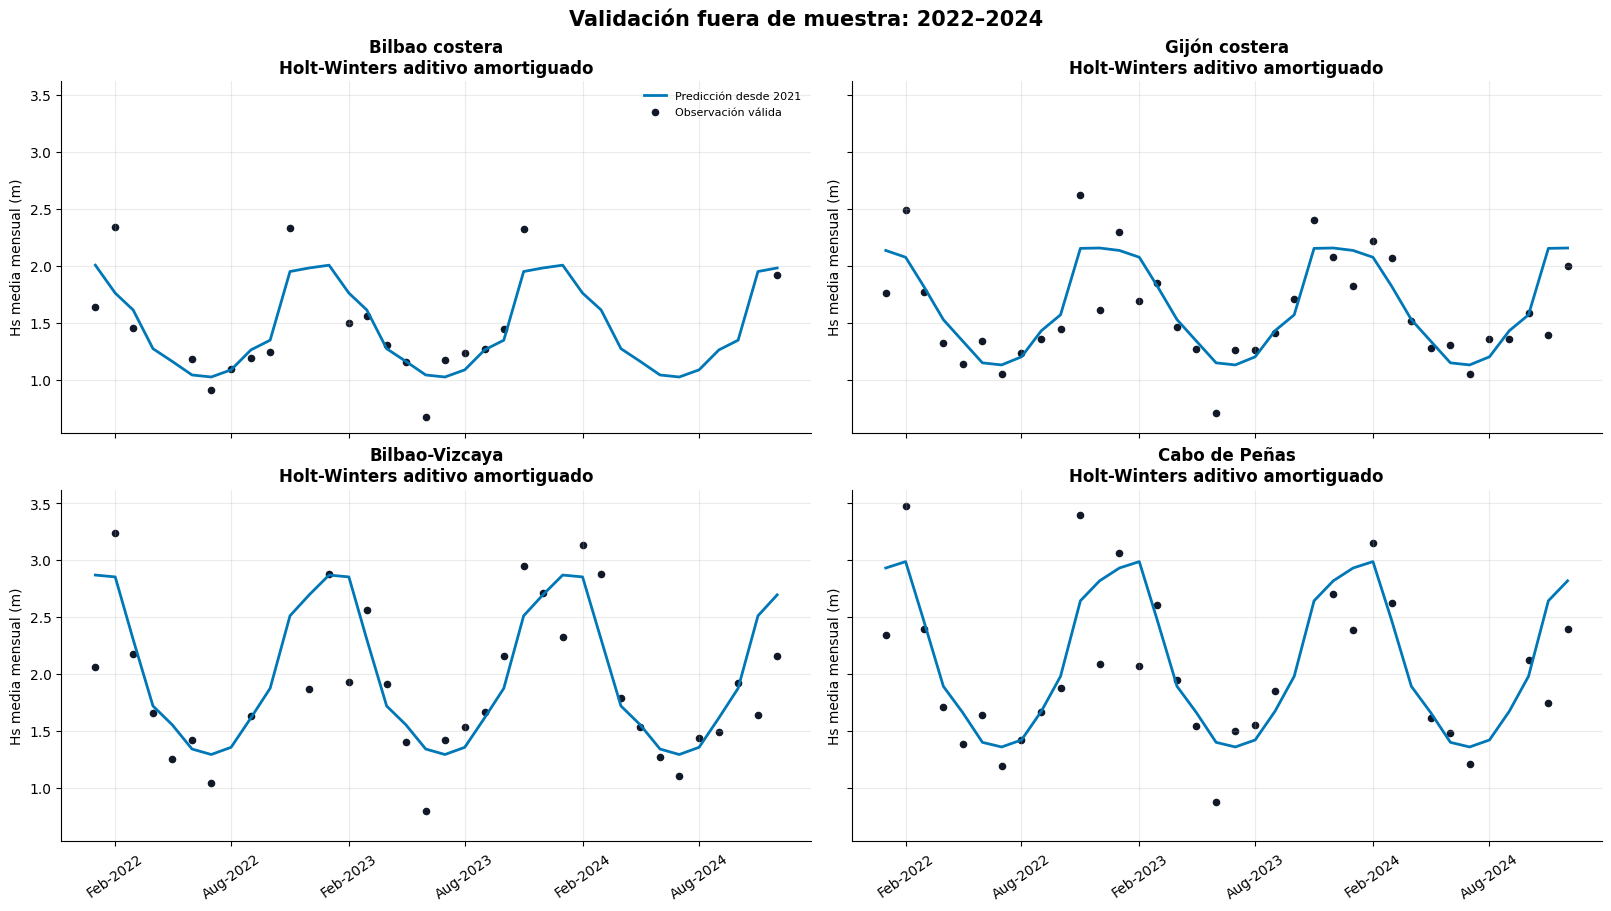

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True, sharey=True, constrained_layout=True)

for ax, nombre in zip(axes.flat, orden_boyas):
    seleccion = tabla_seleccion.loc[
        tabla_seleccion["nombre_boya"] == nombre, "modelo_seleccionado"
    ].iloc[0]
    g = validacion_detalle.loc[
        (validacion_detalle["nombre_boya"] == nombre)
        & (validacion_detalle["modelo"] == seleccion)
    ]
    ax.plot(g["fecha_mes"], g["Hs_predicha_m"], color=COLORES["pronostico"],
            linewidth=2, label="Predicción desde 2021")
    ax.scatter(g["fecha_mes"], g["Hs_observada_m"], color=COLORES["observado"],
               s=20, label="Observación válida")
    ax.set_title(f"{nombre}\n{seleccion}", fontweight="bold")
    ax.set_ylabel("Hs media mensual (m)")
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))
    ax.tick_params(axis="x", rotation=35)

axes.flat[0].legend(loc="upper right", frameon=False, fontsize=8)
fig.suptitle("Validación fuera de muestra: 2022–2024", fontsize=15, fontweight="bold")
fig.savefig(CARPETA_FIGURAS / "02_validacion_2022_2024.png", dpi=220, bbox_inches="tight")
plt.show()

## 5. Ajuste final y predicción de 2027

Después de seleccionar el mejor método para cada boya, se vuelve a ajustar con los 240 meses de 2005–2024. Se calculan 36 valores mensuales, desde enero de 2025 hasta diciembre de 2027, y se extrae el último año.

La banda P10–P90 se obtiene sumando al pronóstico los percentiles 10 y 90 de los errores cometidos durante la validación. Es una **banda empírica de incertidumbre**, no un intervalo de confianza meteorológico exacto.

In [ ]:
fechas_futuras = pd.date_range("2025-01-01", periods=HORIZONTE_MESES, freq="MS")
filas_pronostico = []

for _, info in boyas.iterrows():
    codigo = info["codigo_boya"]
    nombre = info["nombre_boya"]
    g = serie_mensual.loc[serie_mensual["codigo_boya"] == codigo].sort_values("fecha_mes")
    y_completa = imputar_por_mes_del_ano(g)

    sel = tabla_seleccion.loc[tabla_seleccion["codigo_boya"] == codigo].iloc[0]
    modelo_elegido = sel["modelo_seleccionado"]

    if modelo_elegido == "Ingenuo estacional":
        pred = pronostico_ingenuo_estacional(y_completa, fechas_futuras)
    else:
        pred, _ = ajustar_y_predecir_ets(y_completa, fechas_futuras)

    pred = pred.clip(lower=0)
    inferior = (pred + sel["error_p10_m"]).clip(lower=0)
    superior = (pred + sel["error_p90_m"]).clip(lower=0)

    filas_pronostico.append(pd.DataFrame({
        "codigo_boya": codigo,
        "nombre_boya": nombre,
        "fecha": fechas_futuras,
        "Hs_predicha_m": pred.to_numpy(),
        "banda_inferior_p10_m": inferior.to_numpy(),
        "banda_superior_p90_m": superior.to_numpy(),
        "modelo": modelo_elegido,
        "MAE_validacion_m": sel["MAE_m"],
    }))

proyeccion_2025_2027 = pd.concat(filas_pronostico, ignore_index=True)
proyeccion_2025_2027["anio"] = proyeccion_2025_2027["fecha"].dt.year
proyeccion_2025_2027["mes"] = proyeccion_2025_2027["fecha"].dt.month
proyeccion_2025_2027["nombre_mes"] = proyeccion_2025_2027["mes"].map(MESES_ES)

proyeccion_2027 = proyeccion_2025_2027.loc[
    proyeccion_2025_2027["anio"] == 2027
].copy()

columnas_redondeo = [
    "Hs_predicha_m", "banda_inferior_p10_m", "banda_superior_p90_m", "MAE_validacion_m"
]
proyeccion_2027[columnas_redondeo] = proyeccion_2027[columnas_redondeo].round(3)

tabla_2027 = proyeccion_2027.pivot(
    index="nombre_mes", columns="nombre_boya", values="Hs_predicha_m"
).reindex(list(MESES_ES.values()))

print("Predicción de la media mensual de Hs para 2027 (m):")
display(tabla_2027.round(2))

assert len(proyeccion_2025_2027) == 4 * 36
assert len(proyeccion_2027) == 4 * 12
assert (proyeccion_2027["anio"] == 2027).all()
assert (proyeccion_2027["Hs_predicha_m"] >= 0).all()

Predicción de la media mensual de Hs para 2027 (m):


nombre_boya,Bilbao costera,Bilbao-Vizcaya,Cabo de Peñas,Gijón costera
nombre_mes,,,,
Enero,1.94,2.79,2.88,2.09
Febrero,1.77,2.84,2.99,2.08
Marzo,1.60,2.40,2.49,1.84
Abril,1.27,1.74,1.88,1.51
Mayo,1.16,1.52,1.64,1.32
Junio,1.03,1.31,1.39,1.14
Julio,1.02,1.27,1.35,1.13
Agosto,1.10,1.36,1.43,1.21
Septiembre,1.26,1.61,1.68,1.42


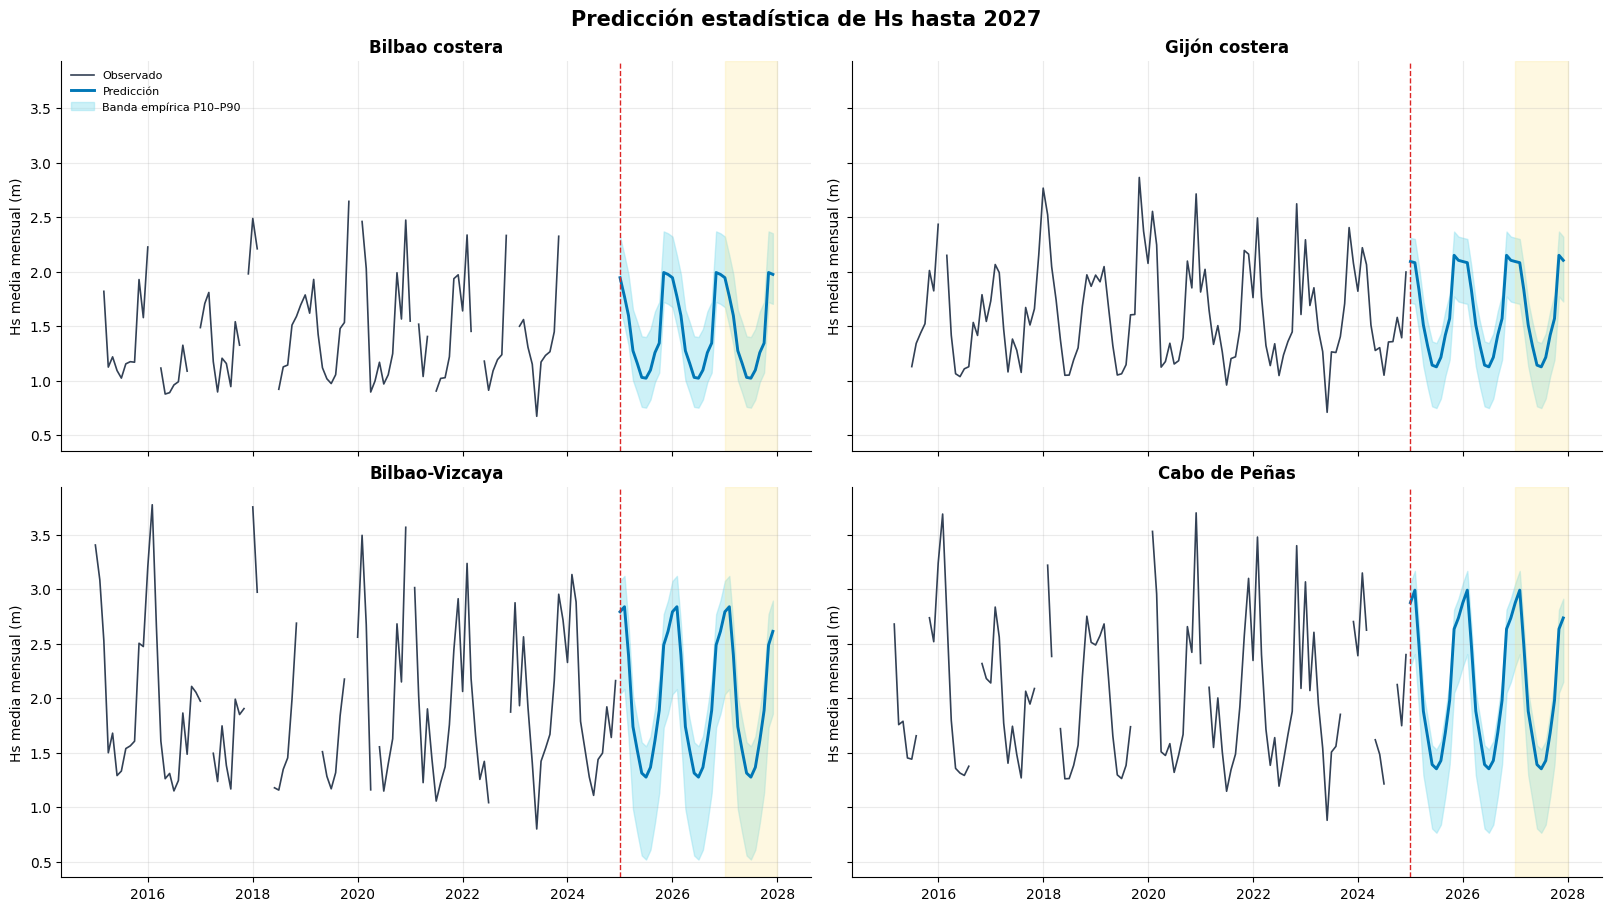

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True, sharey=True, constrained_layout=True)

for ax, nombre in zip(axes.flat, orden_boyas):
    hist = serie_mensual.loc[
        (serie_mensual["nombre_boya"] == nombre)
        & (serie_mensual["fecha_mes"] >= "2015-01-01")
    ]
    fut = proyeccion_2025_2027.loc[proyeccion_2025_2027["nombre_boya"] == nombre]

    ax.plot(hist["fecha_mes"], hist["Hs_media_observada_m"],
            color=COLORES["historico"], linewidth=1.2, label="Observado")
    ax.plot(fut["fecha"], fut["Hs_predicha_m"],
            color=COLORES["pronostico"], linewidth=2.1, label="Predicción")
    ax.fill_between(
        fut["fecha"], fut["banda_inferior_p10_m"], fut["banda_superior_p90_m"],
        color=COLORES["banda"], alpha=0.45, label="Banda empírica P10–P90"
    )
    ax.axvline(pd.Timestamp("2025-01-01"), color="#DC2626", linestyle="--", linewidth=1)
    ax.axvspan(pd.Timestamp("2027-01-01"), pd.Timestamp("2027-12-31"),
               color="#FDE68A", alpha=0.25)
    ax.set_title(nombre, fontweight="bold")
    ax.set_ylabel("Hs media mensual (m)")
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

axes.flat[0].legend(loc="upper left", frameon=False, fontsize=8)
fig.suptitle("Predicción estadística de Hs hasta 2027", fontsize=15, fontweight="bold")
fig.savefig(CARPETA_FIGURAS / "03_prediccion_Hs_2025_2027.png", dpi=220, bbox_inches="tight")
plt.show()

## 6. Contexto direccional e indicadores de exposición histórica

La dirección es circular: 359° y 1° son direcciones próximas, aunque su media aritmética sería errónea. Por ello se agrupa en ocho sectores y se calcula su frecuencia histórica para cada mes.

Para que los porcentajes no queden sesgados, cada combinación boya–año–mes válida se completa con los ocho sectores, asignando cero a los sectores no observados antes de promediar entre años. La suma mensual es, por construcción, 100 %.

También se añaden dos indicadores históricos de contexto:

- P95 horario de Hs del mes;
- porcentaje histórico de horas con Hs ≥ 3 m.


In [ ]:
SECTORES = ["N", "NE", "E", "SE", "S", "SO", "O", "NO"]

datos_dir = datos.loc[
    datos["dir_media_oleaje_grados"].notna()
    & datos["dir_media_oleaje_grados"].between(0, 360, inclusive="both")
].copy()
datos_dir["direccion_normalizada"] = datos_dir["dir_media_oleaje_grados"] % 360
indice_sector = (
    np.floor((datos_dir["direccion_normalizada"] + 22.5) / 45).astype(int) % 8
)
datos_dir["sector"] = pd.Categorical(
    np.array(SECTORES, dtype=object)[indice_sector], categories=SECTORES, ordered=True
)
datos_dir["anio"] = datos_dir["fecha"].dt.year
datos_dir["mes"] = datos_dir["fecha"].dt.month

# Cobertura direccional por boya-año-mes.
cobertura_dir = (
    datos_dir.groupby(["codigo_boya", "nombre_boya", "anio", "mes"], observed=True)
    .size().rename("n_direcciones").reset_index()
)
cobertura_dir["horas_teoricas"] = cobertura_dir.apply(
    lambda r: pd.Period(f"{int(r['anio'])}-{int(r['mes']):02d}", freq="M").days_in_month * 24,
    axis=1,
)
cobertura_dir["valido"] = (
    cobertura_dir["n_direcciones"] / cobertura_dir["horas_teoricas"] >= COBERTURA_MINIMA
)
grupos_validos = cobertura_dir.loc[
    cobertura_dir["valido"], ["codigo_boya", "nombre_boya", "anio", "mes"]
]

dir_valida = datos_dir.merge(
    grupos_validos,
    on=["codigo_boya", "nombre_boya", "anio", "mes"],
    how="inner",
)
conteos = (
    dir_valida.groupby(
        ["codigo_boya", "nombre_boya", "anio", "mes", "sector"], observed=True
    ).size().rename("observaciones").reset_index()
)

# Completar ceros para todos los sectores dentro de cada mes válido.
filas_completas = []
for fila in grupos_validos.itertuples(index=False):
    for sector in SECTORES:
        filas_completas.append((*fila, sector))
rejilla_dir = pd.DataFrame(filas_completas, columns=[
    "codigo_boya", "nombre_boya", "anio", "mes", "sector"
])
dir_anual_mensual = rejilla_dir.merge(
    conteos, on=["codigo_boya", "nombre_boya", "anio", "mes", "sector"], how="left"
)
dir_anual_mensual["observaciones"] = dir_anual_mensual["observaciones"].fillna(0)
dir_anual_mensual["porcentaje"] = 100 * dir_anual_mensual["observaciones"] / (
    dir_anual_mensual.groupby(
        ["codigo_boya", "nombre_boya", "anio", "mes"], observed=True
    )["observaciones"].transform("sum")
)

direccion_mensual = (
    dir_anual_mensual.groupby(
        ["codigo_boya", "nombre_boya", "mes", "sector"], observed=True
    )["porcentaje"].mean().reset_index(name="frecuencia_media_pct")
)

# Normalización final para absorber únicamente posibles errores de redondeo.
direccion_mensual["frecuencia_media_pct"] = 100 * direccion_mensual["frecuencia_media_pct"] / (
    direccion_mensual.groupby(["codigo_boya", "nombre_boya", "mes"], observed=True)[
        "frecuencia_media_pct"
    ].transform("sum")
)

direccion_predominante = (
    direccion_mensual.sort_values(
        ["codigo_boya", "mes", "frecuencia_media_pct"], ascending=[True, True, False]
    )
    .groupby(["codigo_boya", "nombre_boya", "mes"], observed=True, as_index=False)
    .first()
    .rename(columns={
        "sector": "sector_predominante_historico",
        "frecuencia_media_pct": "frecuencia_sector_predominante_pct",
    })
)

# Contexto de Hs calculado únicamente con meses que superan el control de cobertura.
claves_validas_hs = serie_mensual.loc[
    serie_mensual["mes_valido"], ["codigo_boya", "fecha_mes"]
]
datos_contexto = datos.merge(
    claves_validas_hs, on=["codigo_boya", "fecha_mes"], how="inner"
)
datos_contexto["mes"] = datos_contexto["fecha"].dt.month
contexto_historico = (
    datos_contexto.groupby(["codigo_boya", "nombre_boya", "mes"], observed=True)
    .agg(
        Hs_p95_historico_m=("Hs_m", lambda x: x.quantile(0.95)),
        porcentaje_horas_Hs_ge_3=("Hs_m", lambda x: 100 * (x >= 3).mean()),
    )
    .reset_index()
)

sumas = direccion_mensual.groupby(["codigo_boya", "mes"], observed=True)[
    "frecuencia_media_pct"
].sum()
assert np.allclose(sumas.to_numpy(), 100.0, atol=1e-8)
assert len(direccion_mensual) == 4 * 12 * 8

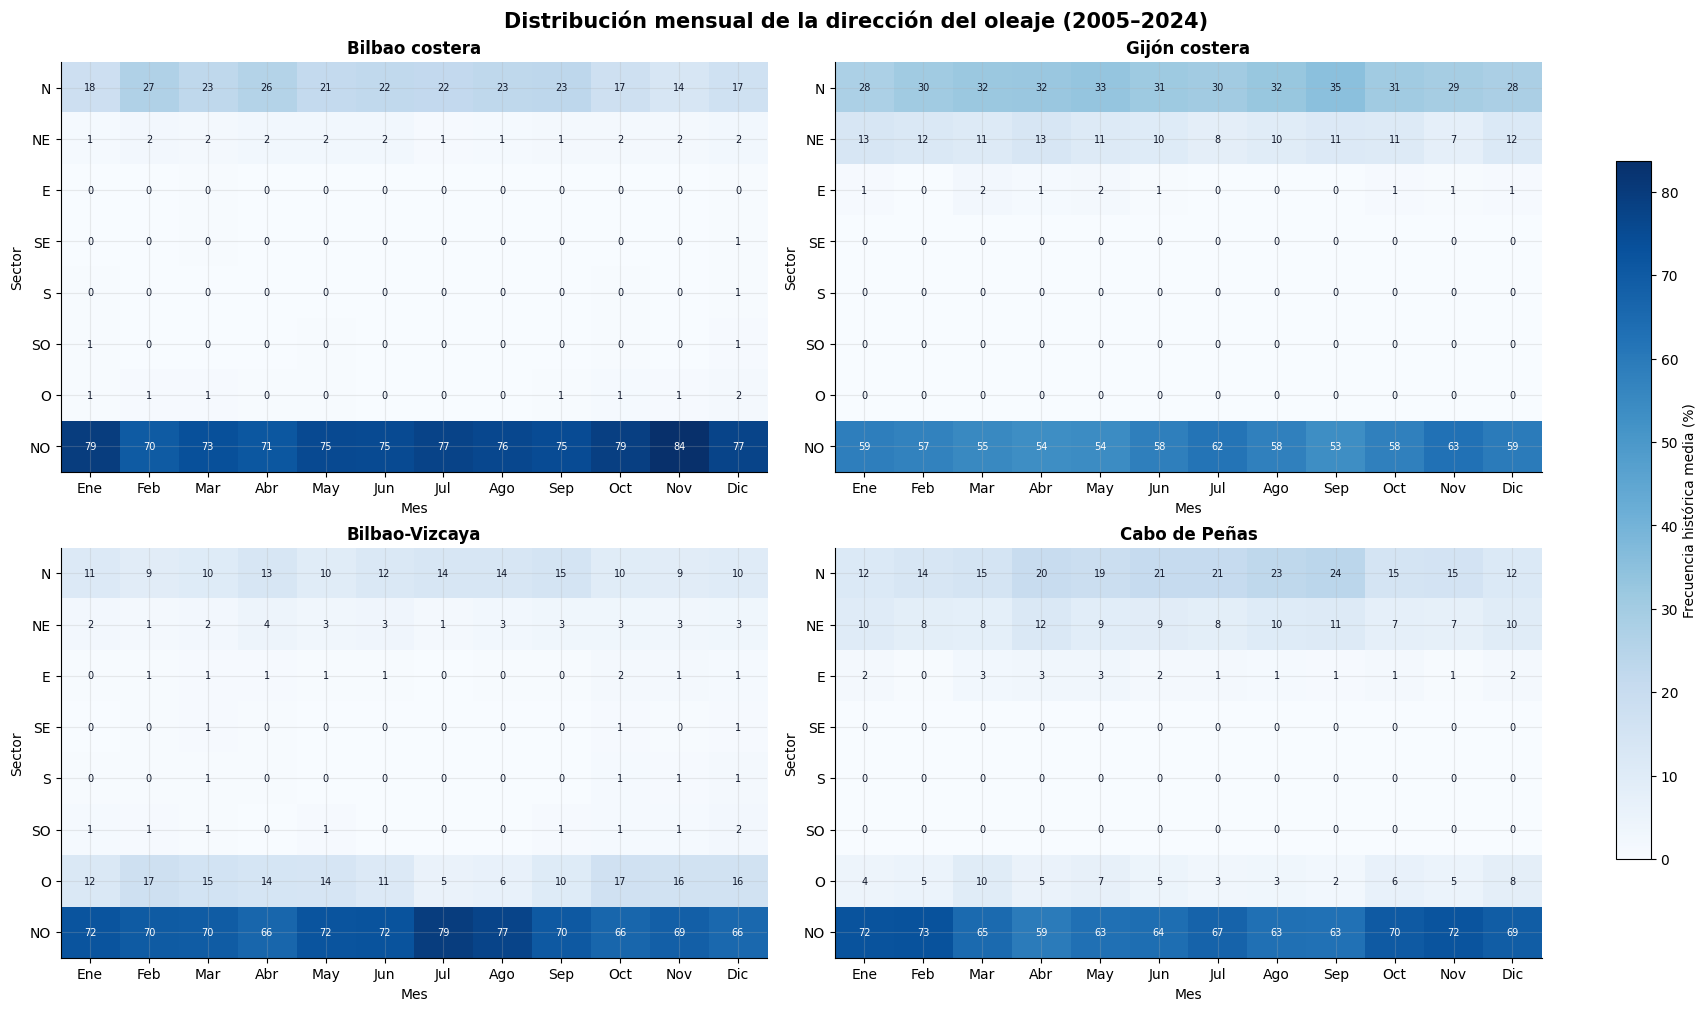

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(17, 10), constrained_layout=True)
vmax = direccion_mensual["frecuencia_media_pct"].max()

for ax, nombre in zip(axes.flat, orden_boyas):
    matriz = (
        direccion_mensual.loc[direccion_mensual["nombre_boya"] == nombre]
        .pivot(index="sector", columns="mes", values="frecuencia_media_pct")
        .reindex(index=SECTORES, columns=range(1, 13))
    )
    im = ax.imshow(matriz.to_numpy(), aspect="auto", cmap="Blues", vmin=0, vmax=vmax)
    ax.set_title(nombre, fontweight="bold")
    ax.set_yticks(range(len(SECTORES)), labels=SECTORES)
    ax.set_xticks(range(12), labels=[MESES_ES[m][:3] for m in range(1, 13)])
    ax.set_xlabel("Mes")
    ax.set_ylabel("Sector")
    for i in range(len(SECTORES)):
        for j in range(12):
            valor = matriz.iloc[i, j]
            color = "white" if valor > vmax * 0.55 else "#0F172A"
            ax.text(j, i, f"{valor:.0f}", ha="center", va="center", fontsize=7, color=color)

fig.colorbar(im, ax=axes, shrink=0.78, label="Frecuencia histórica media (%)")
fig.suptitle("Distribución mensual de la dirección del oleaje (2005–2024)",
             fontsize=15, fontweight="bold")
fig.savefig(CARPETA_FIGURAS / "04_direccion_mensual_historica.png", dpi=220, bbox_inches="tight")
plt.show()

## 7. Tabla de apoyo a la planificación portuaria

La tabla final reúne la predicción mensual de Hs, su banda de incertidumbre y las referencias históricas de intensidad y dirección. El ranking 1 identifica el mes con mayor Hs media prevista dentro de cada boya.

El ranking permite priorizar revisiones estacionales, mantenimiento, disponibilidad de medios y seguimiento reforzado. No representa un semáforo oficial ni un límite de cierre.

In [ ]:
def estacion(mes):
    if mes in (12, 1, 2):
        return "Invierno"
    if mes in (3, 4, 5):
        return "Primavera"
    if mes in (6, 7, 8):
        return "Verano"
    return "Otoño"

tabla_planificacion_2027 = (
    proyeccion_2027.merge(
        contexto_historico, on=["codigo_boya", "nombre_boya", "mes"], how="left"
    )
    .merge(
        direccion_predominante,
        on=["codigo_boya", "nombre_boya", "mes"],
        how="left",
    )
)
tabla_planificacion_2027["estacion"] = tabla_planificacion_2027["mes"].map(estacion)
tabla_planificacion_2027["ranking_Hs_2027"] = (
    tabla_planificacion_2027.groupby("codigo_boya", observed=True)["Hs_predicha_m"]
    .rank(method="first", ascending=False).astype(int)
)

columnas_planificacion = [
    "codigo_boya", "nombre_boya", "fecha", "nombre_mes", "estacion",
    "Hs_predicha_m", "banda_inferior_p10_m", "banda_superior_p90_m",
    "MAE_validacion_m", "ranking_Hs_2027",
    "Hs_p95_historico_m", "porcentaje_horas_Hs_ge_3",
    "sector_predominante_historico", "frecuencia_sector_predominante_pct",
    "modelo",
]
tabla_planificacion_2027 = tabla_planificacion_2027[columnas_planificacion]

for col in [
    "Hs_predicha_m", "banda_inferior_p10_m", "banda_superior_p90_m",
    "MAE_validacion_m", "Hs_p95_historico_m", "porcentaje_horas_Hs_ge_3",
    "frecuencia_sector_predominante_pct",
]:
    tabla_planificacion_2027[col] = tabla_planificacion_2027[col].round(2)

meses_prioritarios = (
    tabla_planificacion_2027.loc[tabla_planificacion_2027["ranking_Hs_2027"] <= 3]
    .sort_values(["codigo_boya", "ranking_Hs_2027"])
)

print("Tres meses con mayor Hs media prevista por boya:")
display(meses_prioritarios[[
    "nombre_boya", "ranking_Hs_2027", "nombre_mes", "Hs_predicha_m",
    "banda_inferior_p10_m", "banda_superior_p90_m",
    "Hs_p95_historico_m", "porcentaje_horas_Hs_ge_3",
    "sector_predominante_historico",
]])

assert len(tabla_planificacion_2027) == 48

Tres meses con mayor Hs media prevista por boya:


,nombre_boya,ranking_Hs_2027,nombre_mes,Hs_predicha_m,banda_inferior_p10_m,banda_superior_p90_m,Hs_p95_historico_m,porcentaje_horas_Hs_ge_3,sector_predominante_historico
10,Bilbao costera,1,Noviembre,1.99,1.72,2.37,3.90,15.15,NO
11,Bilbao costera,2,Diciembre,1.98,1.70,2.35,4.05,14.98,NO
0,Bilbao costera,3,Enero,1.94,1.67,2.32,4.04,15.77,NO
22,Gijón costera,1,Noviembre,2.15,1.77,2.37,4.04,17.95,NO
23,Gijón costera,2,Diciembre,2.10,1.73,2.32,4.31,17.09,NO
12,Gijón costera,3,Enero,2.09,1.72,2.31,4.16,17.68,NO
25,Bilbao-Vizcaya,1,Febrero,2.84,2.08,3.12,5.75,36.66,NO
24,Bilbao-Vizcaya,2,Enero,2.79,2.04,3.08,5.80,35.16,NO
35,Bilbao-Vizcaya,3,Diciembre,2.61,1.86,2.90,5.42,32.13,NO
37,Cabo de Peñas,1,Febrero,2.99,2.40,3.17,5.98,40.37,NO


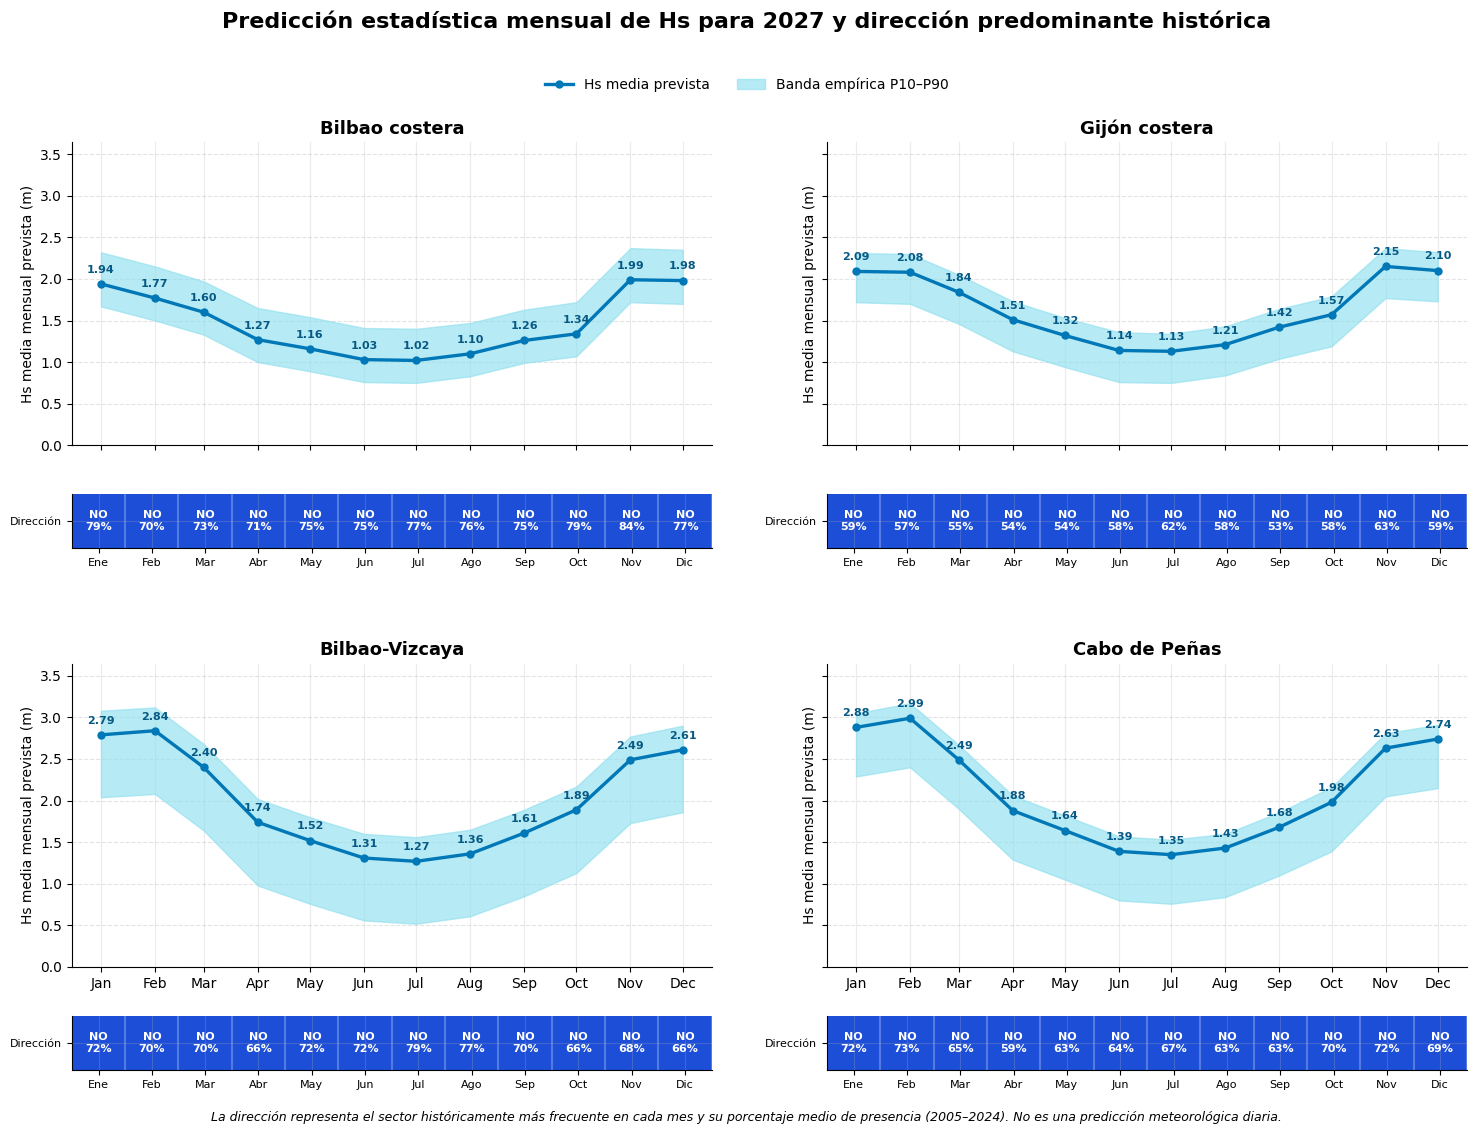

Figura guardada en:
/content/resultados_notebook_06/figuras/05_prediccion_Hs_2027_direccion_probable.png


In [ ]:
# ==========================================================
# Predicción mensual de Hs en 2027 + dirección más probable
# ==========================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap

# La tabla debe haberse creado en las celdas anteriores
grafico_2027 = tabla_planificacion_2027.copy()

# Orden temporal y de las boyas
ORDEN_BOYAS = [
    "Bilbao costera",
    "Gijón costera",
    "Bilbao-Vizcaya",
    "Cabo de Peñas"
]

MESES_CORTOS = [
    "Ene", "Feb", "Mar", "Abr", "May", "Jun",
    "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"
]

grafico_2027["fecha"] = pd.to_datetime(grafico_2027["fecha"])
grafico_2027 = grafico_2027.sort_values(["nombre_boya", "fecha"]).copy()

# Colores para identificar los sectores de procedencia
SECTORES = ["N", "NE", "E", "SE", "S", "SO", "O", "NO"]

COLORES_SECTOR = {
    "N":  "#7DD3FC",
    "NE": "#38BDF8",
    "E":  "#22C55E",
    "SE": "#A3E635",
    "S":  "#FACC15",
    "SO": "#FB923C",
    "O":  "#F97316",
    "NO": "#1D4ED8",
}

MAPA_SECTOR = {sector: i for i, sector in enumerate(SECTORES)}
MAPA_COLOR = ListedColormap([COLORES_SECTOR[sector] for sector in SECTORES])

# Misma escala vertical para comparar las cuatro boyas
limite_superior = (
    grafico_2027["banda_superior_p90_m"].max() * 1.15
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(18, 11),
    sharex=True,
    sharey=True
)

for ax, boya in zip(axes.flat, ORDEN_BOYAS):

    datos_boya = (
        grafico_2027.loc[
            grafico_2027["nombre_boya"] == boya
        ]
        .sort_values("fecha")
        .copy()
    )

    # Línea central: predicción mensual de Hs
    ax.plot(
        datos_boya["fecha"],
        datos_boya["Hs_predicha_m"],
        color="#0077B6",
        marker="o",
        markersize=5,
        linewidth=2.4,
        label="Hs media prevista"
    )

    # Banda de incertidumbre empírica P10-P90
    ax.fill_between(
        datos_boya["fecha"],
        datos_boya["banda_inferior_p10_m"],
        datos_boya["banda_superior_p90_m"],
        color="#90E0EF",
        alpha=0.65,
        label="Banda empírica P10–P90"
    )

    # Etiqueta con el valor previsto de Hs
    for _, fila in datos_boya.iterrows():
        ax.annotate(
            f"{fila['Hs_predicha_m']:.2f}",
            xy=(fila["fecha"], fila["Hs_predicha_m"]),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            fontsize=8,
            color="#075985",
            fontweight="bold"
        )

    ax.set_title(boya, fontsize=13, fontweight="bold")
    ax.set_ylim(0, limite_superior)
    ax.set_ylabel("Hs media mensual prevista (m)")
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

    # ------------------------------------------------------
    # Franja inferior: dirección históricamente más probable
    # ------------------------------------------------------
    ax_direccion = ax.inset_axes([0, -0.34, 1, 0.18])

    valores_sector = [[
        MAPA_SECTOR.get(sector, 0)
        for sector in datos_boya["sector_predominante_historico"]
    ]]

    ax_direccion.imshow(
        valores_sector,
        cmap=MAPA_COLOR,
        vmin=-0.5,
        vmax=7.5,
        aspect="auto"
    )

    ax_direccion.set_xticks(range(12))
    ax_direccion.set_xticklabels(MESES_CORTOS, fontsize=8)
    ax_direccion.set_yticks([0])
    ax_direccion.set_yticklabels(["Dirección"], fontsize=8)

    # Líneas divisorias entre meses
    ax_direccion.set_xticks(
        np.arange(-0.5, 12, 1),
        minor=True
    )
    ax_direccion.grid(
        which="minor",
        color="white",
        linewidth=1.5
    )
    ax_direccion.tick_params(
        which="minor",
        bottom=False,
        left=False
    )

    # Sector predominante y porcentaje dentro de cada mes
    for posicion, (_, fila) in enumerate(datos_boya.iterrows()):

        sector = fila["sector_predominante_historico"]
        porcentaje = fila["frecuencia_sector_predominante_pct"]

        color_texto = "white" if sector in ["O", "NO"] else "#0F172A"

        ax_direccion.text(
            posicion,
            0,
            f"{sector}\n{porcentaje:.0f}%",
            ha="center",
            va="center",
            fontsize=8,
            fontweight="bold",
            color=color_texto
        )

# Leyenda solo una vez
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.97)
)

fig.suptitle(
    "Predicción estadística mensual de Hs para 2027 y dirección predominante histórica",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

fig.text(
    0.5,
    0.01,
    "La dirección representa el sector históricamente más frecuente en cada mes "
    "y su porcentaje medio de presencia (2005–2024). No es una predicción meteorológica diaria.",
    ha="center",
    fontsize=9,
    style="italic"
)

fig.subplots_adjust(
    top=0.90,
    bottom=0.15,
    hspace=0.72,
    wspace=0.18
)

# Guardado de la figura
try:
    ruta_figura = (
        CARPETA_FIGURAS
        / "05_prediccion_Hs_2027_direccion_probable.png"
    )
except NameError:
    ruta_figura = Path(
        "/content/05_prediccion_Hs_2027_direccion_probable.png"
    )

plt.savefig(
    ruta_figura,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada en:")
print(ruta_figura)

## 8. Interpretación correcta de los resultados

La predicción responde a esta pregunta:

> **¿Qué media mensual de Hs cabe esperar en 2027 si continúan el nivel, la tendencia suave y la estacionalidad aprendidos de 2005–2024?**

No responde a estas otras preguntas:

- qué altura tendrá el oleaje en un día concreto de 2027;
- cuándo comenzará un temporal;
- si una maniobra o una terminal debe detenerse;
- cuál será la agitación dentro de una dársena.

Para la gestión portuaria, el uso defendible es **táctico y estacional**: reconocer meses históricamente y estadísticamente más expuestos, programar revisiones o mantenimiento con antelación y reforzar la vigilancia en periodos de mayor Hs prevista. Las decisiones operativas deben combinar predicciones oficiales de corto plazo, geometría del puerto, batimetría, orientación del oleaje y límites específicos de cada actividad.

## 9. Exportación de resultados

Se guardan todas las tablas necesarias para reproducir las figuras y documentar el proceso. La descarga automática está desactivada para evitar ventanas emergentes; basta con cambiar `DESCARGAR_ZIP` a `True` en Google Colab.

In [ ]:
resumen_calidad.to_csv(
    CARPETA_TABLAS / "01_resumen_calidad_20_anios.csv", index=False, encoding="utf-8-sig"
)
serie_mensual.to_csv(
    CARPETA_TABLAS / "02_serie_mensual_calidad_e_imputacion.csv", index=False, encoding="utf-8-sig"
)
tabla_metricas.to_csv(
    CARPETA_TABLAS / "03_metricas_validacion_modelos.csv", index=False, encoding="utf-8-sig"
)
tabla_seleccion.to_csv(
    CARPETA_TABLAS / "04_modelo_seleccionado_por_boya.csv", index=False, encoding="utf-8-sig"
)
proyeccion_2025_2027.to_csv(
    CARPETA_TABLAS / "05_prediccion_Hs_2025_2027.csv", index=False, encoding="utf-8-sig"
)
proyeccion_2027.to_csv(
    CARPETA_TABLAS / "06_prediccion_Hs_2027.csv", index=False, encoding="utf-8-sig"
)
direccion_mensual.to_csv(
    CARPETA_TABLAS / "07_distribucion_direccional_mensual_historica.csv",
    index=False, encoding="utf-8-sig"
)
tabla_planificacion_2027.to_csv(
    CARPETA_TABLAS / "08_apoyo_planificacion_portuaria_2027.csv",
    index=False, encoding="utf-8-sig"
)

ruta_zip = shutil.make_archive(
    str(CARPETA_RESULTADOS / "resultados_notebook_06"), "zip", CARPETA_RESULTADOS
)

print("Tablas generadas:")
for ruta in sorted(CARPETA_TABLAS.glob("*.csv")):
    print(" -", ruta.name)
print("Figuras generadas:")
for ruta in sorted(CARPETA_FIGURAS.glob("*.png")):
    print(" -", ruta.name)
print("ZIP:", ruta_zip)

DESCARGAR_ZIP = False
if DESCARGAR_ZIP:
    try:
        from google.colab import files
        files.download(ruta_zip)
    except ImportError:
        print("La descarga automática solo está disponible en Google Colab.")

Tablas generadas:
 - 01_resumen_calidad_20_anios.csv
 - 02_serie_mensual_calidad_e_imputacion.csv
 - 03_metricas_validacion_modelos.csv
 - 04_modelo_seleccionado_por_boya.csv
 - 05_prediccion_Hs_2025_2027.csv
 - 06_prediccion_Hs_2027.csv
 - 07_distribucion_direccional_mensual_historica.csv
 - 08_apoyo_planificacion_portuaria_2027.csv
Figuras generadas:
 - 01_series_mensuales_calidad.png
 - 02_validacion_2022_2024.png
 - 03_prediccion_Hs_2025_2027.png
 - 04_direccion_mensual_historica.png
ZIP: /content/resultados_notebook_06/resultados_notebook_06.zip


In [ ]:
print("=" * 78)
print("RESUMEN AUTOMÁTICO DEL NOTEBOOK 06")
print("=" * 78)
for _, fila in tabla_seleccion.sort_values("codigo_boya").iterrows():
    print(
        f"{fila['nombre_boya']}: {fila['modelo_seleccionado']} | "
        f"MAE validación = {fila['MAE_m']:.3f} m | "
        f"RMSE = {fila['RMSE_m']:.3f} m"
    )

print("\nMes con mayor Hs media prevista en 2027:")
for _, fila in meses_prioritarios.loc[
    meses_prioritarios["ranking_Hs_2027"] == 1
].iterrows():
    print(
        f"{fila['nombre_boya']}: {fila['nombre_mes']} "
        f"({fila['Hs_predicha_m']:.2f} m), sector histórico predominante "
        f"{fila['sector_predominante_historico']}"
    )

print("\nConclusión: predicción mensual estadística para planificación estacional; ")
print("no es una predicción meteorológica diaria ni un criterio oficial de operatividad.")

RESUMEN AUTOMÁTICO DEL NOTEBOOK 06
Bilbao costera: Holt-Winters aditivo amortiguado | MAE validación = 0.174 m | RMSE = 0.234 m
Gijón costera: Holt-Winters aditivo amortiguado | MAE validación = 0.188 m | RMSE = 0.254 m
Bilbao-Vizcaya: Holt-Winters aditivo amortiguado | MAE validación = 0.286 m | RMSE = 0.393 m
Cabo de Peñas: Holt-Winters aditivo amortiguado | MAE validación = 0.280 m | RMSE = 0.382 m

Mes con mayor Hs media prevista en 2027:
Bilbao costera: Noviembre (1.99 m), sector histórico predominante NO
Gijón costera: Noviembre (2.15 m), sector histórico predominante NO
Bilbao-Vizcaya: Febrero (2.84 m), sector histórico predominante NO
Cabo de Peñas: Febrero (2.99 m), sector histórico predominante NO

Conclusión: predicción mensual estadística para planificación estacional; 
no es una predicción meteorológica diaria ni un criterio oficial de operatividad.


In [ ]:
# ==========================================================
# Crear y descargar automáticamente un ZIP con resultados
# ==========================================================

from pathlib import Path
import shutil

# CARPETA_RESULTADOS debe contener las carpetas:
# /tablas y /figuras creadas en las celdas anteriores.
# Ejemplo: /content/resultados_notebook_06

NOMBRE_ZIP = "resultados_TFM_prediccion_2027"
RUTA_ZIP = Path("/content") / f"{NOMBRE_ZIP}.zip"

# Genera un ZIP único con tablas, figuras y archivos del notebook
shutil.make_archive(
    base_name=str(RUTA_ZIP.with_suffix("")),
    format="zip",
    root_dir=str(CARPETA_RESULTADOS)
)

print("ZIP generado correctamente:")
print(RUTA_ZIP)

print("\nContenido incluido:")
for archivo in sorted(CARPETA_RESULTADOS.rglob("*")):
    if archivo.is_file():
        print(" -", archivo.relative_to(CARPETA_RESULTADOS))

# Descarga automática en Google Colab
from google.colab import files

files.download(str(RUTA_ZIP))

ZIP generado correctamente:
/content/resultados_TFM_prediccion_2027.zip

Contenido incluido:
 - figuras/01_series_mensuales_calidad.png
 - figuras/02_validacion_2022_2024.png
 - figuras/03_prediccion_Hs_2025_2027.png
 - figuras/04_direccion_mensual_historica.png
 - figuras/05_prediccion_Hs_2027_direccion_probable.png
 - resultados_notebook_06.zip
 - tablas/01_resumen_calidad_20_anios.csv
 - tablas/02_serie_mensual_calidad_e_imputacion.csv
 - tablas/03_metricas_validacion_modelos.csv
 - tablas/04_modelo_seleccionado_por_boya.csv
 - tablas/05_prediccion_Hs_2025_2027.csv
 - tablas/06_prediccion_Hs_2027.csv
 - tablas/07_distribucion_direccional_mensual_historica.csv
 - tablas/08_apoyo_planificacion_portuaria_2027.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>